## Overview

In this notebook, I rebuild a small GPT-style autoregressive language model from scratch in PyTorch. The goal is to understand the core components ie token/position embeddings, masked self-attention, Transformer blocks, next-token training, and autoregressive generation.

## Part 1. Implement a minimal GPT model

In this section, I implement a small decoder-only GPT-style language model from scratch in PyTorch.

The model follows this high-level architecture:

Token Embedding + Positional Embedding → Transformer Blocks × L → Linear Language Modeling Head

Each Transformer block contains:

- masked multi-head self-attention
- feed-forward MLP
- residual connections
- layer normalization

The implementation follows the same general GPT design idea as nanoGPT but not copied from nanoGPT.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import math

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


### 1.1 Model Configuration

This configuration stores the main architecture choices in one place.

For Part 1, I use a small model so that it can run easily in Colab:

- context length / block size = 128 tokens
- embedding dimension = 128
- number of attention heads = 4
- number of Transformer layers = 4
- dropout = 0.1
- vocabulary size = 65 for testing

Later, in Part 2, the vocabulary size will come from the actual text dataset.

In [ ]:
@dataclass
class GPTConfig:
    # Maximum number of tokens the model can look at at once.
    block_size: int = 128
    # Number of tokens in the vocabulary - for Part 1 testing.
    vocab_size: int = 65
    # Number of Transformer blocks stacked in the model.
    n_layer: int = 4
    # Number of attention heads inside each self-attention module.
    n_head: int = 4
    # Size of each token embedding vector.
    n_embd: int = 128
    # Dropout probability used for regularization.
    dropout: float = 0.1

### 1.2 Causal Multi-Head Self-Attention

This is the most important part of a decoder-only GPT model.

The self-attention layer lets each token look at earlier tokens in the sequence.  
The causal mask prevents a token from looking at future tokens.

For next-token prediction, this is necessary because the model should not cheat by seeing the answer in advance.

In [ ]:
# Causal multi-head self-attention module.
class CausalSelfAttention(nn.Module):
    # Initialize the attention module.
    def __init__(self, config):
        super().__init__()
        # Check that the embedding dimension can be evenly split across attention heads.
        assert config.n_embd % config.n_head == 0, "n_embd must be divisible by n_head"

        # Store the number of attention heads.
        self.n_head = config.n_head
        # Store the embedding dimension.
        self.n_embd = config.n_embd
        # Compute the size of each attention head.
        self.head_dim = config.n_embd // config.n_head

        # Create the query, key, value projection layers.
        self.query = nn.Linear(config.n_embd, config.n_embd)
        self.key = nn.Linear(config.n_embd, config.n_embd)
        self.value = nn.Linear(config.n_embd, config.n_embd)

        # Create the output projection layer after attention heads are combined.
        self.proj = nn.Linear(config.n_embd, config.n_embd)
        # Create dropout for attention probabilities and after the output projection.
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        # Create a lower-triangular causal mask of shape (block_size, block_size).
        causal_mask = torch.tril(torch.ones(config.block_size, config.block_size, dtype=torch.bool))
        # Reshape the mask to broadcast over batch and heads: (1, 1, block_size, block_size).
        causal_mask = causal_mask.view(1, 1, config.block_size, config.block_size)

        # Register the mask as a buffer so it moves with the model but is not a trainable parameter.
        self.register_buffer("causal_mask", causal_mask)

    # Define the forward pass.
    def forward(self, x):
        # Read batch size B, sequence length T, and embedding size C from input.
        B, T, C = x.shape
        # Project input embeddings into query, key, value vectors.
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Reshape queries, keys, values from (B, T, C) to (B, T, n_head, head_dim).
        q = q.view(B, T, self.n_head, self.head_dim)
        k = k.view(B, T, self.n_head, self.head_dim)
        v = v.view(B, T, self.n_head, self.head_dim)

        # Move the head dimension before the time dimension: (B, n_head, T, head_dim).
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Compute raw attention scores using query-key dot products.
        scores = q @ k.transpose(-2, -1)

        # Scale attention scores by sqrt(head_dim) for stable softmax values.
        scores = scores / math.sqrt(self.head_dim)
        # Select only the part of the causal mask needed for the current sequence length T.
        mask = self.causal_mask[:, :, :T, :T]

        # Put -infinity where the model should not attend, especially future positions.
        scores = scores.masked_fill(mask == False, float("-inf"))

        # Convert attention scores into attention probabilities.
        attn = F.softmax(scores, dim=-1)
        # Apply dropout to attention probabilities.
        attn = self.attn_dropout(attn)
        # Multiply attention probabilities by value vectors to get context vectors.
        out = attn @ v

        # Move the time dimension back before the head dimension: (B, T, n_head, head_dim).
        out = out.transpose(1, 2)
        # Make tensor memory layout contiguous before reshaping.
        out = out.contiguous()
        # Merge all attention heads back into the embedding dimension: (B, T, C).
        out = out.view(B, T, C)
        # Apply final linear projection after combining heads.
        out = self.proj(out)
        # Apply residual dropout after projection.
        out = self.resid_dropout(out)

        # Return the attention output.
        return out

### 1.3 Feed-Forward MLP

After self-attention, each Transformer block uses a small feed-forward network.

The MLP expands the embedding dimension to a larger hidden dimension and then projects it back down.

Here I use:

Linear(n_embd → 4 × n_embd) → GELU → Linear(4 × n_embd → n_embd) → Dropout

In [ ]:
# Feed-forward MLP used inside each Transformer block.
class FeedForward(nn.Module):
    # Initialize the MLP.
    def __init__(self, config):
        super().__init__()

        # First linear layer expands the embedding dimension by 4x.
        self.fc1 = nn.Linear(config.n_embd, 4 * config.n_embd)
        # GELU activation is commonly used in GPT-style Transformers.
        self.gelu = nn.GELU()
        # Second linear layer projects the hidden dimension back to n_embd.
        self.fc2 = nn.Linear(4 * config.n_embd, config.n_embd)
        # Dropout is used for regularization.
        self.dropout = nn.Dropout(config.dropout)

    # Define the forward pass for the MLP.
    def forward(self, x):
        # Apply the first linear layer.
        x = self.fc1(x)
        # GELU nonlinearity.
        x = self.gelu(x)
        # Second linear layer.
        x = self.fc2(x)
        # Dropout.
        x = self.dropout(x)

        # Return the MLP output.
        return x

### 1.4 Transformer Block

Each Transformer block contains:

1. LayerNorm
2. masked multi-head self-attention
3. residual connection
4. LayerNorm
5. feed-forward MLP
6. residual connection

I use the pre-LayerNorm design:

x = x + Attention(LayerNorm(x))  
x = x + MLP(LayerNorm(x))

I think this is stable and easy to understand for a small GPT model.

In [ ]:
# Decoder-only Transformer block.
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # LayerNorm is applied before self-attention.
        self.ln1 = nn.LayerNorm(config.n_embd)

        # Causal self-attention module.
        self.attn = CausalSelfAttention(config)

        # Second LayerNorm is applied before the MLP.
        self.ln2 = nn.LayerNorm(config.n_embd)

        # Feed-forward MLP module.
        self.mlp = FeedForward(config)

    # Forward pass for one Transformer block.
    def forward(self, x):
        # LayerNorm, then attention, then add the residual connection.
        x = x + self.attn(self.ln1(x))

        # LayerNorm, then MLP, then add the residual connection.
        x = x + self.mlp(self.ln2(x))

        # Updated hidden states.
        return x

### 1.5 Full Minimal GPT Model

The full model has the following parts:

1. token embedding table
2. positional embedding table
3. stack of Transformer blocks
4. final LayerNorm
5. linear language-model head

The model receives token IDs with shape (batch, time) and returns logits with shape (batch, time, vocab_size).

If target token IDs are provided, it also returns cross-entropy loss for next-token prediction.

In [ ]:
class MiniGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        # Token embedding table maps token IDs to vectors.
        self.token_embedding = nn.Embedding(config.vocab_size, config.n_embd)

        # Positional embedding table maps token positions to vectors.
        self.position_embedding = nn.Embedding(config.block_size, config.n_embd)

        # Dropout is applied after adding token and position embeddings.
        self.dropout = nn.Dropout(config.dropout)

        # List of Transformer blocks.
        self.blocks = nn.ModuleList([
            TransformerBlock(config) for _ in range(config.n_layer)
        ])

        # Final LayerNorm before the language-model head.
        self.final_ln = nn.LayerNorm(config.n_embd)

        # Linear language-model head maps hidden states to vocabulary logits.
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size)

        # Custom weight initialization to all suitable layers.
        self.apply(self._init_weights)

    # Weight initialization function.
    def _init_weights(self, module):
        # Check whether the module is a Linear layer.
        if isinstance(module, nn.Linear):
            # Initialize Linear layer weights from a normal distribution.
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            # Check whether the Linear layer has a bias term.
            if module.bias is not None:
                # Initialize Linear layer bias values to zero.
                nn.init.zeros_(module.bias)

        # Check whether the module is an Embedding layer.
        elif isinstance(module, nn.Embedding):
            # Initialize Embedding weights from a normal distribution.
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # Count the total number of trainable model parameters.
    def count_parameters(self):
        # Sum the number of elements in every trainable parameter tensor.
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    # Forward pass of the GPT model.
    def forward(self, idx, targets=None):
        # Read batch size B and sequence length T from token ID tensor.
        B, T = idx.shape

        # Make sure the input sequence is not longer than the model context length.
        assert T <= self.config.block_size, "Input sequence is longer than block_size"

        # Create position IDs from 0 to T-1 on the same device as the input.
        pos = torch.arange(0, T, device=idx.device)

        # Convert token IDs into token embeddings of shape (B, T, n_embd).
        tok_emb = self.token_embedding(idx)

        # Convert position IDs into position embeddings of shape (T, n_embd).
        pos_emb = self.position_embedding(pos)

        # Add token embeddings and position embeddings using broadcasting.
        x = tok_emb + pos_emb

        # Dropout after the embedding sum.
        x = self.dropout(x)

        # Pass the hidden states through each Transformer block.
        for block in self.blocks:
            # Update hidden states using one Transformer block.
            x = block(x)

        # Final LayerNorm.
        x = self.final_ln(x)

        # Convert final hidden states into vocabulary logits.
        logits = self.lm_head(x)

        # Start with no loss by default.
        loss = None

        # Compute loss only when target tokens are provided.
        if targets is not None:
            # Flatten logits from (B, T, vocab_size) to (B*T, vocab_size).
            logits_flat = logits.view(B * T, self.config.vocab_size)

            # Flatten targets from (B, T) to (B*T).
            targets_flat = targets.view(B * T)

            # Compute cross-entropy loss for next-token prediction.
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

### 1.6 Create the Model Instance

Here I create a small GPT model using the configuration above.

For Part 1, this is only a structural test.  
The model is not trained yet, so the output predictions will be random.

In [ ]:
# Model configuration object.
config = GPTConfig()

# MiniGPT model using this configuration.
model = MiniGPT(config)

# Move the model to GPU if available, otherwise CPU.
model = model.to(device)

# Count the number of trainable parameters.
num_params = model.count_parameters()

# Model architecture.
print(model)
print(f"\nNumber of trainable parameters: {num_params:,}")

MiniGPT(
  (token_embedding): Embedding(65, 128)
  (position_embedding): Embedding(128, 128)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (query): Linear(in_features=128, out_features=128, bias=True)
        (key): Linear(in_features=128, out_features=128, bias=True)
        (value): Linear(in_features=128, out_features=128, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): FeedForward(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (gelu): GELU(approximate='none')
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace

### 1.7 Forward-Pass Sanity Check

Before training, I test whether the model accepts token IDs and returns the correct output shape.

Expected result:

- input shape: (batch_size, block_size)
- target shape: (batch_size, block_size)
- logits shape: (batch_size, block_size, vocab_size)
- loss: one scalar value

This confirms that the model is ready for the training pipeline in Part 2.

In [ ]:
# Dummy batch size for testing.
batch_size = 4

# Model block size as the dummy sequence length.
sequence_length = config.block_size

# Random input token IDs with shape (batch_size, sequence_length).
dummy_x = torch.randint(
    low=0,
    high=config.vocab_size,
    size=(batch_size, sequence_length),
    device=device
)

# Random target token IDs with the same shape as input.
dummy_y = torch.randint(
    low=0,
    high=config.vocab_size,
    size=(batch_size, sequence_length),
    device=device
)

# Model forward pass using dummy input and targets.
logits, loss = model(dummy_x, dummy_y)

print("Input shape: ", dummy_x.shape)
print("Target shape:", dummy_y.shape)
print("Logits shape:", logits.shape)
print("Loss:", loss.item())

# Check that logits have the expected shape.
assert logits.shape == (batch_size, sequence_length, config.vocab_size)
# Check that loss is a scalar tensor.
assert loss.ndim == 0
print("\nSanity check passed: model forward pass works correctly.")

Input shape:  torch.Size([4, 128])
Target shape: torch.Size([4, 128])
Logits shape: torch.Size([4, 128, 65])
Loss: 4.209580421447754

Sanity check passed: model forward pass works correctly.


### 1.8 Causal Mask Check

This cell checks that the self-attention mask has the correct lower-triangular structure.

A lower-triangular mask means:

- token 0 can attend only to token 0
- token 1 can attend to tokens 0 and 1
- token 2 can attend to tokens 0, 1, and 2
- future tokens are blocked

This is the key idea behind autoregressive GPT-style prediction.

In [ ]:
# First Transformer block from the model.
first_block = model.blocks[0]

# Causal mask from the attention module inside the first block.
mask = first_block.attn.causal_mask

# First 8 by 8 part of the mask for easy viewing.
small_mask = mask[0, 0, :8, :8]

# Move the mask to CPU and convert it to integer values for printing.
small_mask = small_mask.cpu().int()

print(small_mask)

tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)


### 1.9 Architecture Choices

For Part 1, I implemented a minimal decoder-only GPT model with the following architecture:

- Vocabulary size: 65  
  This is a placeholder value for the Part 1 dummy test. In Part 2, this will be replaced by the actual vocabulary size from the text dataset.

- Context length / block size: 128  
  The model can look at up to 128 previous tokens when predicting the next token. This is small enough for Colab but still enough to demonstrate causal language modeling.

- Embedding dimension: 128  
  Each token is represented as a 128-dimensional vector. This keeps the model lightweight.

- Number of Transformer layers: 4  
  The model uses 4 stacked Transformer blocks. This is enough to show the core GPT architecture without making the notebook too slow.

- Number of attention heads: 4  
  The embedding dimension is split across 4 attention heads. Each head has dimension 32.

- MLP hidden size: 4 × embedding dimension = 512  
  Each Transformer block uses a feed-forward MLP that expands the embedding dimension and then projects it back down.

- Dropout: 0.1  
  Dropout is included for regularization, especially useful when training on a small text dataset.

The model contains the required components:

1. Token embedding
2. Positional embedding
3. Masked multi-head self-attention
4. Feed-forward MLP
5. Residual connections
6. Layer normalization
7. Linear language-model head

The forward-pass sanity check confirms that the model produces logits of shape:

(batch_size, sequence_length, vocab_size)

and computes a scalar cross-entropy loss when target token IDs are provided.

## Part 2. Implement the Training Pipeline

In this section, I implement the full training pipeline for the small GPT model created in Part 1.

The training pipeline includes:

1. Loading a small text dataset (Shakespeare Dataset
)
2. Building a character-level tokenizer
3. Creating train and validation splits
4. Forming input and target sequences for next-token prediction
5. Sampling minibatches
6. Training the GPT model using AdamW
7. Periodically evaluating train and validation loss
8. Logging losses
9. Plotting training and validation loss curves

This section focuses only on training logic. Text generation and qualitative evaluation will be done in Part 3.

In [ ]:
import os
import requests
import time
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

### 2.1 Load Tiny Shakespeare Dataset

For this training pipeline, I use Tiny Shakespeare as a small character-level language modeling dataset.

In [ ]:
input_file_path = "input.txt"

if not os.path.exists(input_file_path):

    print("Downloading Tiny Shakespeare dataset")
    # URL for the Tiny Shakespeare dataset.
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

    # Download
    response = requests.get(url)
    # If the download failed.
    response.raise_for_status()

    with open(input_file_path, "w", encoding="utf-8") as f:

        # Write into the local file.
        f.write(response.text)

# If the file already exists.
else:
    print("input.txt already exists. Using the existing file.")

with open(input_file_path, "r", encoding="utf-8") as f:

    # Read the entire dataset as one long string.
    text = f.read()

print("Total number of characters in dataset:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Total number of characters in dataset: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### 2.2 Character-Level Tokenization

I use character-level tokenization.

This means each unique character in the dataset becomes one token.

Example:

"hello" → [token_h, token_e, token_l, token_l, token_o]

I think this is simple, transparent, and suitable here because our focus is on understanding how GPT training works.

In [ ]:
# Sorted list of unique characters in the dataset.
chars = sorted(list(set(text)))

# Number of unique characters.
vocab_size = len(chars)

# Dictionary that maps each character to an integer token ID.
stoi = {ch: i for i, ch in enumerate(chars)}

# Dictionary that maps each integer token ID back to a character.
itos = {i: ch for i, ch in enumerate(chars)}

# Encode a string into a list of integer token IDs.
def encode(s):

    # Convert each character in the string into its integer ID.
    return [stoi[ch] for ch in s]

# Decode a list of integer token IDs back into a string.
def decode(ids):

    # Convert each integer ID back into a character and join them into one string.
    return "".join([itos[i] for i in ids])

print("Vocabulary size:", vocab_size)
print("Unique characters:")
print("".join(chars))

# Test the tokenizer.
sample_text = "Hello"

# Encode only characters that exist in the vocabulary.
sample_encoded = encode(sample_text)

# Decode the encoded token IDs back to text.
sample_decoded = decode(sample_encoded)

print("\nOriginal:", sample_text)
print("Encoded:", sample_encoded)
print("Decoded:", sample_decoded)

Vocabulary size: 65
Unique characters:

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Original: Hello
Encoded: [20, 43, 50, 50, 53]
Decoded: Hello


### 2.3 Convert Text to Token Tensor and Split into Train/Validation Sets

The full text is converted into one long tensor of token IDs.

Then I split it into:

- 90% training data
- 10% validation data

The training set is used for optimizer updates.  
The validation set is used only to estimate generalization loss.

In [ ]:
# Encode the full dataset into a list of integer token IDs.
data_ids = encode(text)

# List of token IDs into a PyTorch tensor.
data = torch.tensor(data_ids, dtype=torch.long)

# Index where the 90% training split ends.
n = int(0.9 * len(data))

# First 90% of tokens as training data.
train_data = data[:n]

# Remaining 10% of tokens as validation data.
val_data = data[n:]

print("Total tokens:", len(data))
print("Training tokens:", len(train_data))
print("Validation tokens:", len(val_data))

Total tokens: 1115394
Training tokens: 1003854
Validation tokens: 111540


### 2.4 Training Hyperparameters

These values control training.

As I use Colab, I use a small setup so the model can train reasonably fast.

The most important values are:

- batch_size: number of independent sequences per batch
- block_size: context length
- max_iters: number of training updates
- eval_interval: how often to compute train/validation loss
- learning_rate: optimizer step size

In [ ]:
# Set the batch size
# ie how many independent sequences are processed together.
batch_size = 32

# Set the context length
# ie meaning how many previous tokens the model can see.
block_size = 128

# Set the maximum number of training iterations.
max_iters = 3000

# Set how often we evaluate train and validation loss.
eval_interval = 300

# Set how many batches are averaged during evaluation.
eval_iters = 100

# Set the learning rate for AdamW.
learning_rate = 3e-4

# Set dropout probability for the GPT model.
dropout = 0.1

# Main training settings.
print("batch_size:", batch_size, "block_size:", block_size, "max_iters:", max_iters,
      "eval_interval:", eval_interval, "learning_rate:", learning_rate)

batch_size: 32 block_size: 128 max_iters: 3000 eval_interval: 300 learning_rate: 0.0003


### 2.5 Create Minibatches for Next-Token Prediction

For language modeling, the target sequence is the input sequence shifted by one token.

Example:

Input:  "hell"  
Target: "ello"

The model receives the input tokens and learns to predict the next token at every position.

In [ ]:
# Sample a minibatch from either train or validation data.
def get_batch(split):

    # Select training/validation data.
    source_data = train_data if split == "train" else val_data

    # Choose starting positions for each sequence in the batch.
    ix = torch.randint(len(source_data) - block_size, (batch_size,))

    # Input sequences of length block_size from random positions.
    x = torch.stack([source_data[i:i + block_size] for i in ix])

    # Target sequences by shifting input sequences one token to the right.
    y = torch.stack([source_data[i + 1:i + block_size + 1] for i in ix])

    # Move input, target batch to GPU if available.
    x = x.to(device)
    y = y.to(device)

    return x, y

# Sample one training batch to check.
xb, yb = get_batch("train")

print("Input batch shape:", xb.shape, "Target batch shape:", yb.shape)
print("\nFirst input example:\n")
print(decode(xb[0].cpu().tolist()))
print("\nFirst target example:\n")
print(decode(yb[0].cpu().tolist()))

Input batch shape: torch.Size([32, 128]) Target batch shape: torch.Size([32, 128])

First input example:

bune
And hale him up and down, all swearing, if
The Roman ladies bring not comfort home,
They'll give him death by inches.

SICI

First target example:

une
And hale him up and down, all swearing, if
The Roman ladies bring not comfort home,
They'll give him death by inches.

SICIN


### 2.6 Create the Model for Training

In Part 1, the model used a placeholder vocabulary size.

Now I recreate the model using the real vocabulary size from the dataset.

This is necessary because the final language-model head must output one logit for each character in the dataset vocabulary.

In [ ]:
# GPT configuration using the dataset vocabulary size.
train_config = GPTConfig(
    block_size=block_size,
    vocab_size=vocab_size,
    n_layer=4,
    n_head=4,
    n_embd=128,
    dropout=dropout
)

# MiniGPT model for training.
model = MiniGPT(train_config)

# Move the model to GPU if available.
model = model.to(device)

# Number of trainable parameters.
num_params = model.count_parameters()

print(f"Number of trainable parameters: {num_params:,}")

# Forward pass to make sure the model and data work together.
logits, loss = model(xb, yb)

print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Number of trainable parameters: 826,433
Logits shape: torch.Size([32, 128, 65])
Initial loss: 4.200011253356934


### 2.7 Optimizer

I use AdamW to update the model parameters.

AdamW is commonly used for Transformer training because it combines Adam-style adaptive learning rates with decoupled weight decay.

In [ ]:
# AdamW optimizer using all trainable model parameters.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.01
)


### 2.8 Periodic Train/Validation Loss Estimation

During training, I periodically estimate the average loss on both the training split and validation split.

This helps us see:

- whether the model is learning
- whether training loss is decreasing
- whether validation loss is also improving
- whether the model may be overfitting

I use torch.no_grad() here because evaluation does not need gradients.

In [ ]:
# Disable gradient tracking for evaluation.
@torch.no_grad()
def estimate_loss():

    # Store train and validation losses.
    out = {}

    # Model in evaluation mode.
    model.eval()

    # Loop over both train and validation splits.
    for split in ["train", "val"]:

        # Store loss values from multiple batches.
        losses = torch.zeros(eval_iters)

        # Evaluate several random batches.
        for k in range(eval_iters):

            # Sample a batch from the selected split.
            X, Y = get_batch(split)

            # Run the model forward pass.
            logits, loss = model(X, Y)

            # Store the scalar loss value on CPU.
            losses[k] = loss.item()

        # Store the average loss for this split.
        out[split] = losses.mean().item()

    # Model back into training mode.
    model.train()

    return out

# Initial loss before training.
initial_losses = estimate_loss()

print("Initial train loss:", initial_losses["train"])
print("Initial val loss:", initial_losses["val"])

Initial train loss: 4.2051544189453125
Initial val loss: 4.204398155212402


### 2.9 Training Loop (baseline)

This is the main training loop.

Each iteration does the following:

1. Sample a minibatch
2. Run a forward pass
3. Compute cross-entropy loss
4. Clear old gradients
5. Run backpropagation
6. Update parameters with AdamW
7. Periodically evaluate train and validation loss
8. Save losses for plotting

In [ ]:
# Lists to store iteration numbers, training losses, validation losses.
eval_steps = []
train_losses = []
val_losses = []

# Starting time of training.
start_time = time.time()

# Loop over training iterations.
for iter_num in range(max_iters + 1):

    # Check if it is time to evaluate the model.
    if iter_num % eval_interval == 0:

        # Average train and validation losses.
        losses = estimate_loss()

        # Current iteration number.
        eval_steps.append(iter_num)

        # Training loss.
        train_losses.append(losses["train"])

        # Validation loss.
        val_losses.append(losses["val"])

        # Current progress.
        print(
            f"Step {iter_num:4d} | "
            f"Train loss: {losses['train']:.4f} | "
            f"Val loss: {losses['val']:.4f}"
        )

    # Sample a batch of input and target token sequences.
    xb, yb = get_batch("train")

    # Run the model forward pass and compute loss.
    logits, loss = model(xb, yb)

    # Clear old gradients from the previous iteration.
    optimizer.zero_grad(set_to_none=True)

    # Backpropagate the loss through the model.
    loss.backward()

    # Update model parameters using AdamW.
    optimizer.step()

# Record the ending time of training.
end_time = time.time()

# Compute total training time in seconds.
training_time = end_time - start_time
print(f"\nTraining completed in {training_time:.2f} seconds.")

Step    0 | Train loss: 4.2049 | Val loss: 4.2050
Step  300 | Train loss: 2.4387 | Val loss: 2.4407
Step  600 | Train loss: 2.2510 | Val loss: 2.2595
Step  900 | Train loss: 2.0721 | Val loss: 2.1178
Step 1200 | Train loss: 1.9357 | Val loss: 2.0233
Step 1500 | Train loss: 1.8293 | Val loss: 1.9360
Step 1800 | Train loss: 1.7387 | Val loss: 1.8780
Step 2100 | Train loss: 1.6643 | Val loss: 1.8343
Step 2400 | Train loss: 1.6146 | Val loss: 1.7898
Step 2700 | Train loss: 1.5638 | Val loss: 1.7477
Step 3000 | Train loss: 1.5304 | Val loss: 1.7236

Training completed in 50.79 seconds.


### 2.10 Plot Training and Validation Loss (baseline)

The loss curve shows whether the model learned from the text data.


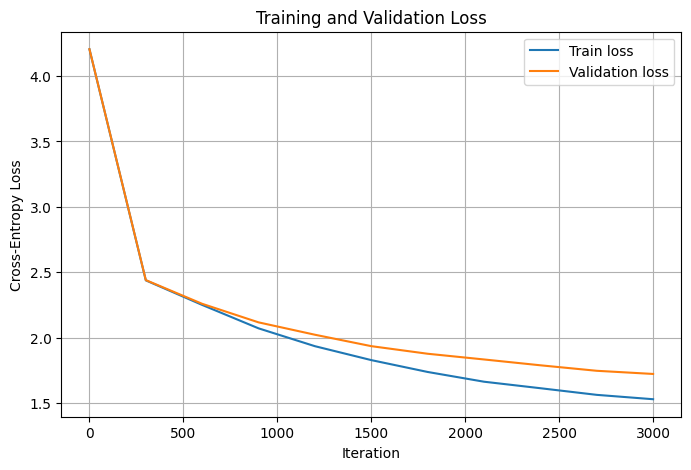

In [ ]:
plt.figure(figsize=(8, 5))

# Plot training loss against evaluation steps.
plt.plot(eval_steps, train_losses, label="Train loss")

# Plot validation loss against evaluation steps.
plt.plot(eval_steps, val_losses, label="Validation loss")

plt.title("Training and Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")

plt.legend()
plt.grid(True)
plt.show()

The training and validation loss curves show that the model is learning well. At step 0, both losses are around 4.20, which means the model starts almost randomly. As training continues, both losses steadily decrease, with training loss reaching 1.53 and validation loss reaching 1.72 by step 3000. This means the model is learning useful patterns from the Tiny Shakespeare text and is also improving on unseen validation data. The validation loss is slightly higher than the training loss, which is normal because validation data is not used for weight updates.

Since the validation loss is still going down and not increasing, there is no clear sign of serious overfitting yet -  overfitting usually appears when training loss keeps decreasing but validation loss starts increasing.

### 2.11 Final Training Log Table

This table summarizes the train and validation losses recorded during training.

In [ ]:
# Loop over the saved evaluation records.
for step, train_loss, val_loss in zip(eval_steps, train_losses, val_losses):

    # Training/validation loss record.
    print(
        f"Step {step:4d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

Step    0 | Train loss: 4.2049 | Val loss: 4.2050
Step  300 | Train loss: 2.4387 | Val loss: 2.4407
Step  600 | Train loss: 2.2510 | Val loss: 2.2595
Step  900 | Train loss: 2.0721 | Val loss: 2.1178
Step 1200 | Train loss: 1.9357 | Val loss: 2.0233
Step 1500 | Train loss: 1.8293 | Val loss: 1.9360
Step 1800 | Train loss: 1.7387 | Val loss: 1.8780
Step 2100 | Train loss: 1.6643 | Val loss: 1.8343
Step 2400 | Train loss: 1.6146 | Val loss: 1.7898
Step 2700 | Train loss: 1.5638 | Val loss: 1.7477
Step 3000 | Train loss: 1.5304 | Val loss: 1.7236


## Part 3. Train on a Small Text Dataset (Tiny Shakespeare) & Evaluate Qualitatively

In this section, I evaluate the trained GPT model qualitatively.

The goal is not to build a state-of-the-art language model.  
The goal is to show that the small GPT model learned useful patterns from the dataset.

This section includes:

1. A short dataset and tokenization description
2. Final train/validation loss reporting
3. Loss curve visualization
4. Autoregressive text generation
5. Several generated samples
6. A short qualitative discussion

### 3.1 Dataset and Tokenization Choice

I used the Tiny Shakespeare dataset.

This is a small text corpus containing Shakespeare-style dialogue. It is suitable for this assignment because it is small enough to train quickly in Colab, but still has enough structure for the model to learn names, punctuation, line breaks, and word-like patterns.

I used character-level tokenization.

In character-level tokenization, each unique character is treated as one token. This makes the tokenizer simple and easy to implement from scratch. The disadvantage is that the model must learn words from characters, so it usually needs more steps to produce coherent long text compared with subword tokenization.

### 3.2 Train MiniGPT for Strong Tiny Shakespeare Performance

In this section, I train the MiniGPT model with a stronger configuration for Tiny Shakespeare.

The earlier Part 2 settings were good for verifying that the training pipeline works.  
Here, I use a larger character-level GPT model inspired by the nanoGPT Shakespeare configuration:

- 6 Transformer layers
- 6 attention heads
- 384-dimensional embeddings
- context length of 256 characters
- batch size of 64
- dropout of 0.2
- AdamW optimizer
- warmup + cosine learning-rate decay
- gradient clipping
- mixed precision training on GPU

The goal is to get the best practical qualitative performance in Colab while still keeping the implementation understandable.

### 3.3 Stronger Hyperparameter Configuration

In [ ]:
import math
import time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
# Dropout = 0.2 for regularization on this small dataset.
dropout = 0.2
# Maximum number of training iterations.
max_iters = 5000
# Interval for validation evaluation.
eval_interval = 250
# Number of batches used to estimate train/validation loss.
eval_iters = 200

# Maximum learning rate.
learning_rate = 1e-3
# Minimum learning rate for cosine decay.
min_lr = 1e-4

# Number of warmup iterations.
warmup_iters = 100
# Set cosine decay duration equal to the total number of iterations.
lr_decay_iters = max_iters
# Set AdamW beta1.
beta1 = 0.9
# Set AdamW beta2 slightly higher because the dataset and batches are small.
beta2 = 0.99
# Weight decay for regularization.
weight_decay = 1e-1

# Gradient clipping threshold.
grad_clip = 1.0

Using device: cuda


In [ ]:
print("Dataset and Tokenization Summary")
print("-" * 40)
print("Dataset: Tiny Shakespeare")
print("Tokenization: Character-level tokenization")

print("Vocabulary size:", vocab_size)
print("Context length / block size:", block_size)
print("Training tokens:", len(train_data))
print("Validation tokens:", len(val_data))

# First few characters in the vocabulary.
print("Vocabulary characters:")
print("".join(chars))

Dataset and Tokenization Summary
----------------------------------------
Dataset: Tiny Shakespeare
Tokenization: Character-level tokenization
Vocabulary size: 65
Context length / block size: 256
Training tokens: 1003854
Validation tokens: 111540
Vocabulary characters:

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


### 3.4 Recreate get_batch for Block Size 256

In [ ]:
def get_batch(split):

    # Select the correct data split.
    source_data = train_data if split == "train" else val_data

    # Sample starting positions for each sequence in the batch.
    ix = torch.randint(len(source_data) - block_size, (batch_size,))

    # Build input sequences of length block_size.
    x = torch.stack([source_data[i:i + block_size] for i in ix])

    # Build target sequences shifted one character forward.
    y = torch.stack([source_data[i + 1:i + block_size + 1] for i in ix])

    # Move input,target batch to the selected device.
    x = x.to(device)
    y = y.to(device)

    return x, y

# Sample one batch to confirm the shape.
xb, yb = get_batch("train")

print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)

Input batch shape: torch.Size([64, 256])
Target batch shape: torch.Size([64, 256])


### 3.5 Create a stronger MiniGPT Model

In [ ]:
# Create a stronger GPT configuration for Tiny Shakespeare.
strong_config = GPTConfig(
    block_size=block_size,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd,
    dropout=dropout
)

# MiniGPT model using the stronger configuration.
model = MiniGPT(strong_config)

model = model.to(device)

# Tie token embedding weights and output head weights if their shapes match.
# This usually improves parameter efficiency and is a common GPT-style trick.
if model.token_embedding.weight.shape == model.lm_head.weight.shape:

    # Share the same weight tensor between token embedding and language-model head.
    model.lm_head.weight = model.token_embedding.weight
    print("Weight tying enabled")

# Number of trainable parameters.
num_params = model.count_parameters()
print(f"Number of trainable parameters: {num_params / 1e6:.2f}M")

# Forward pass to confirm the model works.
logits, loss = model(xb, yb)

print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Weight tying enabled
Number of trainable parameters: 10.77M
Logits shape: torch.Size([64, 256, 65])
Initial loss: 4.286757469177246


### 3.6 AdamW with Better Parameter Groups

In [ ]:
# Dictionary of all trainable parameters.
param_dict = {name: param for name, param in model.named_parameters() if param.requires_grad}

# Select parameters with dimension 2 or more for weight decay.
decay_params = [param for name, param in param_dict.items() if param.dim() >= 2]

# Dimension less than 2 for no weight decay.
nodecay_params = [param for name, param in param_dict.items() if param.dim() < 2]

# Optimizer parameter groups.
optim_groups = [
    {"params": decay_params, "weight_decay": weight_decay},
    {"params": nodecay_params, "weight_decay": 0.0},
]

# Create the AdamW optimizer.
optimizer = torch.optim.AdamW(
    optim_groups,
    lr=learning_rate,
    betas=(beta1, beta2)
)

print("Number of decayed parameter tensors:", len(decay_params))
print("Number of non-decayed parameter tensors:", len(nodecay_params))

Number of decayed parameter tensors: 38
Number of non-decayed parameter tensors: 63


### 3.7 Learning Rate Schedule

A learning rate schedule controls how big the model’s parameter updates are during training. It is used because one fixed learning rate is not always ideal: if it is too large at the beginning, training can become unstable; if it stays too large near the end, the model may not settle into a good solution.

Here we use warmup + cosine decay. In the warmup stage, the learning rate starts small and slowly increases to the maximum value, so the model begins training safely. After that, cosine decay slowly reduces the learning rate in a smooth curve until it reaches a small minimum value. This helps the model learn fast at first, then make smaller and more careful updates near the end. nanoGPT also uses cosine decay with warmup in its training loop. PyTorch also provides cosine-based learning-rate schedulers for smoothly reducing the learning rate during training.

In [ ]:
def get_lr(iter_num):

    # During warmup, increase learning rate linearly.
    if iter_num < warmup_iters:

        # Linearly warmed-up learning rate.
        return learning_rate * (iter_num + 1) / warmup_iters

    # After decay period, keep learning rate fixed at min_lr.
    if iter_num > lr_decay_iters:

        # Minimum learning rate.
        return min_lr

    # How far we are through the cosine decay period.
    decay_ratio = (iter_num - warmup_iters) / (lr_decay_iters - warmup_iters)

    # Decay_ratio is inside the expected range.
    assert 0 <= decay_ratio <= 1

    # Compute cosine decay coefficient.
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))

    # Decayed learning rate.
    return min_lr + coeff * (learning_rate - min_lr)

print("LR at step 0:", get_lr(0))
print("LR at warmup end:", get_lr(warmup_iters))
print("LR at final step:", get_lr(max_iters))

LR at step 0: 1e-05
LR at warmup end: 0.001
LR at final step: 0.0001


### 3.8 Mixed Precision Setup

Mixed precision usually makes GPU training faster and reduces memory usage. PyTorch AMP uses autocast and GradScaler for this style of training.

In [ ]:
# Enable mixed precision only when CUDA GPU is available.
use_amp = device == "cuda"

# GradScaler for mixed precision training.
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print("Mixed precision enabled:", use_amp)

Mixed precision enabled: True


/tmp/ipykernel_1740/20242496.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [ ]:
# Disable gradient tracking during evaluation.
@torch.no_grad()
def estimate_loss():

    out = {}

    # Put the model in evaluation mode.
    model.eval()

    # Loop over train and validation splits.
    for split in ["train", "val"]:

        losses = torch.zeros(eval_iters)

        # Evaluate multiple batches.
        for k in range(eval_iters):

            # Get one batch.
            X, Y = get_batch(split)

            # Use autocast during evaluation if GPU mixed precision is enabled.
            with torch.cuda.amp.autocast(enabled=use_amp):

                # Run forward pass.
                logits, loss = model(X, Y)

            # Store scalar loss.
            losses[k] = loss.item()

        # Store average loss for this split.
        out[split] = losses.mean().item()

    # Put model back into training mode.
    model.train()

    # Return train and validation losses.
    return out

# Estimate starting loss.
start_losses = estimate_loss()

print("Initial train loss:", start_losses["train"])
print("Initial val loss:", start_losses["val"])

/tmp/ipykernel_1740/873119905.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Initial train loss: 4.284268856048584
Initial val loss: 4.287939071655273


### 3.9 Training Loop with Best Checkpoint

In [ ]:
eval_steps = []
train_losses = []
val_losses = []

# Validation loss to infinity before training.
best_val_loss = float("inf")

# Model state to None before training.
best_model_state = None

# Record the training start time.
start_time = time.time()

# Loop through training iterations.
for iter_num in range(max_iters + 1):

    # GLearning rate for this iteration.
    lr = get_lr(iter_num)

    # Learning rate to each optimizer parameter group.
    for param_group in optimizer.param_groups:

        # Set the learning rate.
        param_group["lr"] = lr

    # Periodically evaluate train and validation loss.
    if iter_num % eval_interval == 0:

        # Estimate losses.
        losses = estimate_loss()

        # Store current iteration.
        eval_steps.append(iter_num)

        # Store train loss.
        train_losses.append(losses["train"])

        # Store validation loss.
        val_losses.append(losses["val"])

        print(
            f"Step {iter_num:5d} | "
            f"LR {lr:.6f} | "
            f"Train loss {losses['train']:.4f} | "
            f"Val loss {losses['val']:.4f}"
        )

        # Check whether validation loss improved.
        if losses["val"] < best_val_loss:

            best_val_loss = losses["val"]

            # Save model state on CPU to avoid GPU memory pressure.
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            print(f"New best validation loss: {best_val_loss:.4f}")

    # Sample a training batch.
    xb, yb = get_batch("train")

    # Clear previous gradients.
    optimizer.zero_grad(set_to_none=True)

    # Use mixed precision autocast during the forward pass.
    with torch.cuda.amp.autocast(enabled=use_amp):

        # Run the model and compute loss.
        logits, loss = model(xb, yb)

    # Scale loss and run backward pass.
    scaler.scale(loss).backward()

    # Unscale gradients before clipping.
    scaler.unscale_(optimizer)

    # Clip gradients to stabilize training.
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

    # Step the optimizer using the scaler.
    scaler.step(optimizer)

    # Update the scaler for the next iteration.
    scaler.update()

# Record the training end time.
end_time = time.time()

# Total training time.
training_time = end_time - start_time

print(f"\nTraining completed in {training_time / 60:.2f} minutes.")
print(f"Best validation loss: {best_val_loss:.4f}")

/tmp/ipykernel_1740/873119905.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Step     0 | LR 0.000010 | Train loss 4.2846 | Val loss 4.2879
New best validation loss: 4.2879


/tmp/ipykernel_1740/2053201370.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Step   250 | LR 0.000998 | Train loss 2.0165 | Val loss 2.1092
New best validation loss: 2.1092
Step   500 | LR 0.000985 | Train loss 1.5393 | Val loss 1.7313
New best validation loss: 1.7313
Step   750 | LR 0.000961 | Train loss 1.3673 | Val loss 1.5928
New best validation loss: 1.5928
Step  1000 | LR 0.000927 | Train loss 1.2749 | Val loss 1.5274
New best validation loss: 1.5274
Step  1250 | LR 0.000883 | Train loss 1.2070 | Val loss 1.4982
New best validation loss: 1.4982
Step  1500 | LR 0.000831 | Train loss 1.1554 | Val loss 1.4819
New best validation loss: 1.4819
Step  1750 | LR 0.000771 | Train loss 1.0990 | Val loss 1.4780
New best validation loss: 1.4780
Step  2000 | LR 0.000705 | Train loss 1.0527 | Val loss 1.4796
Step  2250 | LR 0.000636 | Train loss 1.0092 | Val loss 1.4861
Step  2500 | LR 0.000564 | Train loss 0.9556 | Val loss 1.4944
Step  2750 | LR 0.000492 | Train loss 0.9081 | Val loss 1.5137
Step  3000 | LR 0.000422 | Train loss 0.8607 | Val loss 1.5308
Step  3250 | 

### 3.10 Plot Training Loss Curves

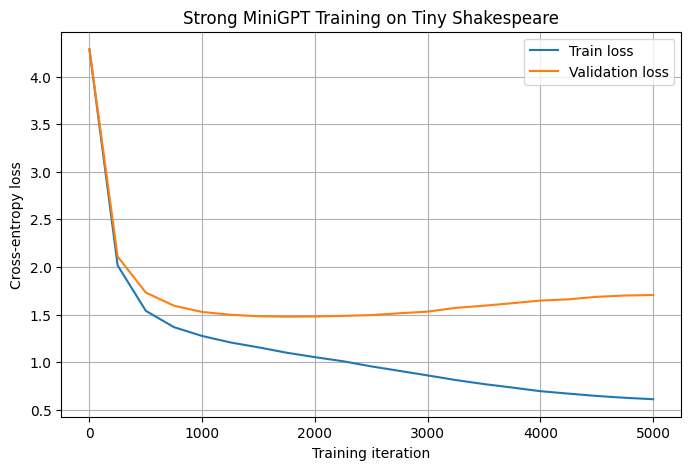

In [ ]:
plt.figure(figsize=(8, 5))

# Plot training loss.
plt.plot(eval_steps, train_losses, label="Train loss")

# Plot validation loss.
plt.plot(eval_steps, val_losses, label="Validation loss")

plt.title("Strong MiniGPT Training on Tiny Shakespeare")

plt.xlabel("Training iteration")
plt.ylabel("Cross-entropy loss")

plt.legend()
plt.grid(True)

# Display plot.
plt.show()

The stronger model learns much faster and reaches a much better validation loss than the Part 2 baseline. In Part 2, validation loss decreased from 4.20 to 1.72 after 3000 steps. In Part 3, validation loss quickly dropped from 4.29 to the best value of 1.4780 by step 1750, which is close to the nanoGPT Tiny Shakespeare reference result of around 1.47 validation loss. After step 1750, training loss kept decreasing from 1.09 to 0.61, but validation loss started increasing from 1.4780 to 1.7055. This means the model began to overfit: it kept memorizing the training text better, but it stopped improving on unseen validation text.

So the best model is not the final step 5000 model; the best checkpoint is at step 1750, where validation loss was lowest.

### 3.11 Load Best Model

In [ ]:
# Check whether a best model state was saved.
if best_model_state is not None:

    # Load the best model weights back into the model.
    model.load_state_dict({
        key: value.to(device)
        for key, value in best_model_state.items()
    })

    # Print confirmation.
    print("Loaded best validation checkpoint.")

# Estimate final losses after loading the best model.
final_losses = estimate_loss()

print("Final train loss:", final_losses["train"])
print("Final validation loss:", final_losses["val"])

Loaded best validation checkpoint.


/tmp/ipykernel_1740/873119905.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Final train loss: 1.1009124517440796
Final validation loss: 1.478519082069397


### 3.12 Strong Generation Function

In [ ]:
# Disable gradient tracking for text generation.
@torch.no_grad()
def generate_text(model, start_text="\n", max_new_tokens=800, temperature=0.8, top_k=200):

    # Put model in evaluation mode.
    model.eval()

    # Encode starting prompt into token IDs.
    start_ids = encode(start_text)

    # Convert token IDs to tensor with batch dimension.
    idx = torch.tensor([start_ids], dtype=torch.long, device=device)

    # Generate one token at a time.
    for _ in range(max_new_tokens):

        # Crop context to block_size if needed.
        idx_cond = idx[:, -model.config.block_size:]

        # Run model forward pass.
        logits, _ = model(idx_cond)

        # Select logits from the last time step.
        logits = logits[:, -1, :]

        # Apply temperature scaling.
        logits = logits / temperature

        # Apply top-k filtering if requested.
        if top_k is not None:

            # Keep no more than vocabulary size.
            k = min(top_k, logits.size(-1))

            # Find top-k logits.
            values, indices = torch.topk(logits, k=k)

            # Create filtered logits filled with -infinity.
            filtered_logits = torch.full_like(logits, float("-inf"))

            # Scatter top-k values into filtered logits.
            filtered_logits.scatter_(dim=-1, index=indices, src=values)

            # Replace logits with filtered logits.
            logits = filtered_logits

        # Convert logits into probabilities.
        probs = torch.softmax(logits, dim=-1)

        # Sample next token ID.
        next_id = torch.multinomial(probs, num_samples=1)

        # Append sampled token ID.
        idx = torch.cat([idx, next_id], dim=1)

    # Decode generated token IDs into text.
    output_text = decode(idx[0].tolist())

    # Put model back in training mode.
    model.train()

    # Return generated text.
    return output_text

### 3.13 Generate High-Quality Samples

In [ ]:
# Prompts for qualitative evaluation.
prompts = [
    "\n",
    "ROMEO:",
    "KING:",
    "JULIET:",
    "To be"
]

# Loop over all prompts.
for prompt in prompts:

    # Generate text from the current prompt.
    sample = generate_text(
        model=model,
        start_text=prompt,
        max_new_tokens=800,
        temperature=0.8,
        top_k=200
    )

    print("\n" + "-" * 80)
    print(f"Prompt: {repr(prompt)}")
    print("-" * 80)

    # Generated text.
    print(sample)


--------------------------------------------------------------------------------
Prompt: '\n'
--------------------------------------------------------------------------------

She which she hath death seen his prey daughter:
It is too much not leads; but to know the right.

PARIS:
No, by God's deed, but I fear the sea
Which would have the strange for the degree.
Three protectors upon the blocks of Fresh death,
Which impress'd his daughter death by the flesh;
I may be use to be terror
About down before this loss and keep the lewd;
Why, then for, therefore life to live,
This for a brokened point of lightning slumbs!

KING RICHARD III:
Ay, have I been my mother's deed;
And therefore I beseech you, at quiet,
I am once a vost and turn your in this fortune in the heels;
And never say you there is no more word;
And all my supposed, if you shall entreat of him.
But, sovereign and your behalf abroad!
He was a forerun and lock'd with mine heaven,
And in my knavy inherity:

---------------------

The our best model generates much better samples than the baseline model. The text now looks more like Shakespeare dialogue: it uses speaker names such as ROMEO, JULIET, KING RICHARD III, and CORIOLANUS, creates line breaks, and produces sentence structures that match the training style. The samples are not fully meaningful, and some words or phrases are still strange, but the model clearly learned the format, rhythm, punctuation, and character-dialogue pattern of Tiny Shakespeare. This matches the expected behavior for a small character-level model: it can learn local text structure well, but long-range meaning is still limited. nanoGPT also evaluates Tiny Shakespeare generation qualitatively by sampling text after training, not by expecting perfect language output.

### 3.14 Save Best Model and Samples

In [ ]:
# Create a checkpoint dictionary.
checkpoint = {
    "model_state_dict": model.state_dict(),
    "config": strong_config,
    "stoi": stoi,
    "itos": itos,
    "eval_steps": eval_steps,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": best_val_loss,
}

# Save the checkpoint.
torch.save(checkpoint, "strong_minigpt_tiny_shakespeare.pt")

# Generate one final long sample.
final_sample = generate_text(
    model=model,
    start_text="ROMEO:",
    max_new_tokens=1500,
    temperature=0.8,
    top_k=200
)

with open("strong_minigpt_generated_sample.txt", "w", encoding="utf-8") as f:

    # Write the final sample.
    f.write(final_sample)

print("Saved model checkpoint")
print("Saved generated sample")

Saved model checkpoint
Saved generated sample


### 3.15 Effect of Temperature

To study the effect of temperature, I generated two samples using the same prompt.

In [ ]:
# Generate text with a lower temperature.
sample_low_temp = generate_text(
    model=model,
    start_text="ROMEO:",
    max_new_tokens=1500,
    temperature=0.7,
    top_k=200
)

# Generate text with a higher temperature.
sample_high_temp = generate_text(
    model=model,
    start_text="ROMEO:",
    max_new_tokens=1500,
    temperature=1.2,
    top_k=200
)

print("Low Temperature Sample: temperature = 0.7")
print("-" * 60)
print(sample_low_temp)

print("\n")

print("High Temperature Sample: temperature = 1.2")
print("-" * 60)
print(sample_high_temp)

Low Temperature Sample: temperature = 0.7
------------------------------------------------------------
ROMEO:
The were in the time and child
Is the case great from the treasure of thee.

Messenger:
I think it were possessors with noble sons,
As far of him of disgraced as you labour
To think you with price and the contrary:
I have done the rather of his contraction
May be set on the true clouds to see our blood,
That seem upon his free walls in sorrows,
And he is struck not with a staffrer's dear.

CLIFFORD:
Then storm of the book of mine advance;
For of all wretched by a temples of my kinsman,
Did not speed to our kingly sleep in his sons.

KING RICHARD III:
But any comon that noble eyes to see it?

KING RICHARD III:
There is the more words than a time
Than our subject to your deeds: but they stand in them,
My mindering hath he contemn'd them for their tears.

RUTLAND:
Now, my good lord, I will drown the deep.

KING RICHARD III:
Well, let the day of the early walls:
And we have stood t

The temperature experiment shows the expected behavior. With temperature = 0.7, the model generates more stable and Shakespeare-like text. It keeps better structure, uses speaker names correctly, and the sentences are more controlled, but it is also more repetitive. With temperature = 1.2, the output becomes more creative and varied, but it also becomes less coherent. It produces more strange spellings, unusual words, and broken phrases such as "Junaccustical," "nonelbows," and "minuteous." This happens because lower temperature makes the model choose high-probability characters more often, while higher temperature gives more chance to lower-probability characters, increasing randomness.

So for this trained MiniGPT model, 0.7 gives better readability, while 1.2 gives more diversity but lower quality.

### 3.16 Qualitative Evaluation

**Overall result**

The trained model learned clear and useful patterns from the Tiny Shakespeare dataset. In the Part 2 baseline model, the validation loss reached 1.7236. After using the stronger model in Part 3, the best validation loss improved to 1.4780. This is a strong improvement and is close to the nanoGPT Tiny Shakespeare reference result of around 1.47 validation loss.

**Comparison with the Part 2 baseline**
- Part 2 baseline validation loss: 1.7236
- Part 3 stronger model best validation loss: 1.4780
- Improvement: the stronger model learned the dataset better and generated more realistic Shakespeare-style text.

The Part 2 model was good enough to show that the training pipeline works. But the Part 3 model is better because it uses a larger architecture, longer context length, better training settings, and checkpoint selection based on the best validation loss.

**Quality of generated samples**

The generated samples show that the model learned the style and structure of the dataset. In the samples, the model produces:

- character names such as ROMEO, JULIET, KING RICHARD III, CORIOLANUS, and MENENIUS
- dialogue-like structure
- line breaks similar to Shakespeare text
- punctuation patterns
- short word-like and sentence-like structures
- Shakespeare-style rhythm in some places

The samples are not perfect. Some sentences are not meaningful, and the model sometimes creates strange words. But overall, the output clearly looks like text from the Tiny Shakespeare dataset. This is expected because the model is trained at character level, so it learns spelling, names, punctuation, and local structure first.

**Training behavior**

The stronger model learned very quickly. The validation loss improved until around step 1750, where it reached the best value of 1.4780. After that, the training loss continued to decrease, but the validation loss started increasing.

This means the model started to overfit after step 1750.

- Training loss kept going down because the model was fitting the training text better.
- Validation loss increased because the model was no longer improving on unseen text.
- So the best model is the checkpoint at step 1750, not the final model at step 5000.

This is why saving the best checkpoint based on validation loss is important. nanoGPT also follows this idea by saving the best checkpoint with the lowest validation loss.

**Factors affecting performance**

**1. Model size**

The stronger model performed better because it used:

- more Transformer layers
- more attention heads
- larger embedding dimension

This gave the model more capacity to learn richer patterns from the text. The baseline model was smaller, so it could learn the basic structure, but the stronger model learned the style more clearly.

**2. Context length**

The stronger model used a larger context length. This means it could look at more previous characters before predicting the next character.

A longer context helps the model understand:

- speaker names
- line structure
- longer phrases
- dialogue flow

But it also uses more GPU memory.

**3. Training time**

Training longer helped only up to a point. Until step 1750, the model improved on validation data. After that, it started overfitting.

So more training is not always better. The best point is where validation loss is lowest.

**4. Tokenization granularity**

I used character-level tokenization. This is simple and good for rebuilding GPT from scratch.

It helps the model learn:

- spelling
- punctuation
- line breaks
- character names

But it also makes sequences longer because each word is split into characters. A subword tokenizer may improve word-level coherence, but it is more complex and less suitable for a simple from-scratch implementation.

**5. Sampling settings**

Temperature and top-k sampling also affected the generated text.

Lower temperature gave more stable and readable text.
Higher temperature gave more creative text, but also more strange words and broken phrases.
Top-k sampling helped limit the model to more likely next characters.

So sampling settings are important for the final quality of generated samples.

### Overall

The stronger Part 3 model is a clear improvement over the Part 2 baseline. It achieved much lower validation loss and generated better Shakespeare-style text. The model is still not fully coherent, but it successfully demonstrates the full GPT workflow: character tokenization, next-token prediction, training and validation loss tracking, checkpoint selection, and autoregressive text generation.